# A convolutional network, layer by layer

### What a convolution buys that a dense layer cannot

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a convolution computes, and why weight sharing is the whole trick. What the filters actually learn. And a fair comparison against a dense network with a similar parameter budget |
| **You should already know** | [The PyTorch training loop](../../07-neural-networks/03-the-same-net-in-pytorch/) |
| **Dataset** | Fashion-MNIST (70,000 images, 28×28 greyscale, 10 classes) |
| **Runtime** | Four to six minutes on a laptop CPU, under two on a GPU |
| **Next** | [08-04 Data augmentation](../04-data-augmentation/) · [08-05 Transfer learning](../05-transfer-learning/) |

---

## 1. The idea

A dense layer treats a 28×28 image as 784 unrelated numbers. It has no idea that
pixel 100 sits beside pixel 101 and above pixel 128. Shift a shoe two pixels
right and every input changes; as far as the layer is concerned it is a
completely different picture, and it must learn the shoe again in the new position.

A convolution starts from the fact that **nearby pixels are related** and that
**a useful pattern is useful anywhere in the image**. So it learns one small
filter, say 3×3, and slides it across the whole image, reusing the same nine
weights at every position.

Two consequences follow, and they are the entire reason convolutions won.

**Far fewer parameters.** A dense layer mapping 784 inputs to 784 outputs needs
615,440 parameters. A 3×3 filter needs 9, whatever the size of the image.

**Translation equivariance.** A pattern learned in one corner is detected in
every corner for free, because it is literally the same weights doing the looking.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

train_set = datasets.fashion_mnist(train=True)
test_set = datasets.fashion_mnist(train=False)
CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]
print(f"{len(train_set):,} training images, {len(test_set):,} test images, 28x28 greyscale")

torch 2.11.0+cu128 on cuda


60,000 training images, 10,000 test images, 28x28 greyscale


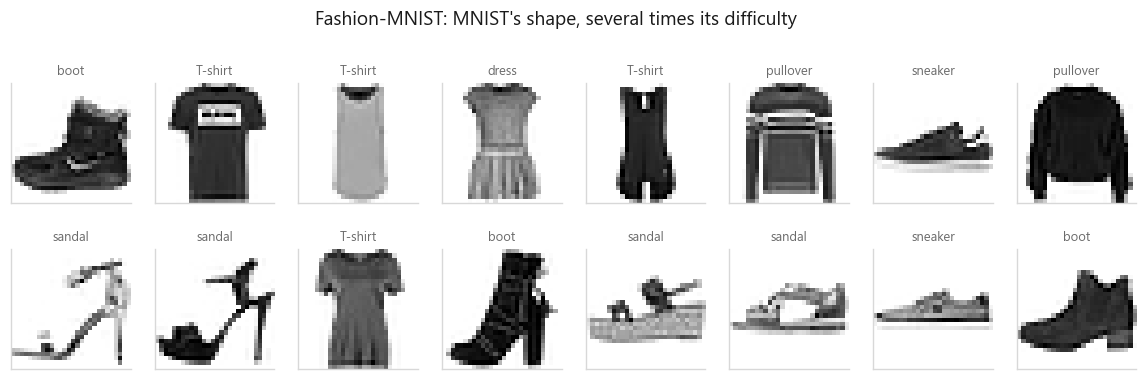

In [2]:
fig, axes = plt.subplots(2, 8, figsize=(13.2, 3.6))
for ax, index in zip(axes.ravel(), range(16)):
    image, label = train_set[index]
    ax.imshow(image.squeeze(), cmap="gray_r")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(CLASSES[label], fontsize=8.5, color=style.MUTED)
fig.suptitle("Fashion-MNIST: MNIST's shape, several times its difficulty",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-the-data.png")

## 2. What a convolution actually computes

Slide a small grid of weights over the image. At each position, multiply
element-wise and sum:

$$(I * K)(i, j) = \sum_{m}\sum_{n} I(i+m,\; j+n)\, K(m, n)$$

$I$ is the image, $K$ is the small grid of weights, $(i, j)$ is the output pixel
being computed, and $m$ and $n$ walk over the grid, so $I(i+m, j+n)$ is whichever
image pixel currently lies under $K(m, n)$.

Different filters detect different things, and the classic hand-designed ones
make it concrete before any learning happens.

a 3x3 filter has 9 weights regardless of image size
a dense layer from 784 pixels to 784 outputs has 615,440


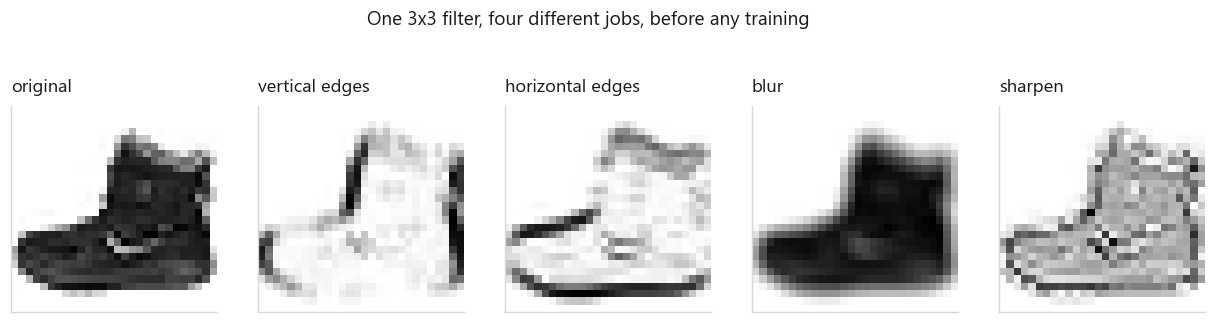

In [3]:
image, label = train_set[0]
image_t = image.unsqueeze(0)

kernels = {
    "original": None,
    "vertical edges": [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],       # Sobel x
    "horizontal edges": [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],     # Sobel y
    "blur": [[1/9]*3] * 3,
    "sharpen": [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
}

fig, axes = plt.subplots(1, len(kernels), figsize=(14.0, 3.2))
for ax, (name, kernel) in zip(axes, kernels.items()):
    if kernel is None:
        shown = image.squeeze()
    else:
        weight = torch.tensor(kernel, dtype=torch.float32).view(1, 1, 3, 3)
        shown = F.conv2d(image_t, weight, padding=1).squeeze().abs()
    ax.imshow(shown, cmap="gray_r")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    style.title(ax, name)
fig.suptitle("One 3x3 filter, four different jobs, before any training",
             x=0.5, y=1.06, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-what-a-filter-does.png")

print("a 3x3 filter has 9 weights regardless of image size")
print(f"a dense layer from 784 pixels to 784 outputs has {784 * 784 + 784:,}")

**Pooling** is the other half. After convolving, take the maximum in each 2×2
block. That halves the resolution, which cuts computation and, more importantly,
makes the representation tolerant to small shifts: the strongest response in a
neighbourhood survives whether it landed at the top or the bottom of it.

## 3. The network

In [4]:
class SmallCNN(nn.Module):
    """Two convolutional blocks, then a classifier. The standard starting shape."""

    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # 1 channel in, 16 filters out. Padding 1 keeps the 28x28 size.
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                                  # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                                  # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class DenseNet(nn.Module):
    """A fully connected network sized to a comparable parameter budget."""

    def __init__(self, n_classes=10, width=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, width), nn.ReLU(),
            nn.Linear(width, width), nn.ReLU(),
            nn.Linear(width, n_classes),
        )

    def forward(self, x):
        return self.net(x)


cnn, dense = SmallCNN(), DenseNet()
count = lambda m: sum(p.numel() for p in m.parameters())
print(f"convolutional network : {count(cnn):,} parameters")
print(f"dense network         : {count(dense):,} parameters")

convolutional network : 105,866 parameters


dense network         : 118,282 parameters


## 4. Training both

In [5]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000)


def run(model, epochs=6, lr=0.05):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = {"val_acc": [], "epoch_seconds": []}

    for _ in range(epochs):
        started = time.perf_counter()
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad()
            loss_fn(model(xb), yb).backward()
            optimiser.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb.to(device)).sum().item()
                total += len(yb)
        history["val_acc"].append(correct / total)
        history["epoch_seconds"].append(time.perf_counter() - started)
    return model, history


torch.manual_seed(SEED)
cnn, cnn_history = run(SmallCNN())
torch.manual_seed(SEED)
dense, dense_history = run(DenseNet())

print(f"convolutional : {cnn_history['val_acc'][-1]:.4f} after 6 epochs")
print(f"dense         : {dense_history['val_acc'][-1]:.4f} after 6 epochs")
print(f"seconds per epoch: conv {np.mean(cnn_history['epoch_seconds']):.1f}, "
      f"dense {np.mean(dense_history['epoch_seconds']):.1f}")

convolutional : 0.8948 after 6 epochs
dense         : 0.8678 after 6 epochs
seconds per epoch: conv 14.7, dense 15.2


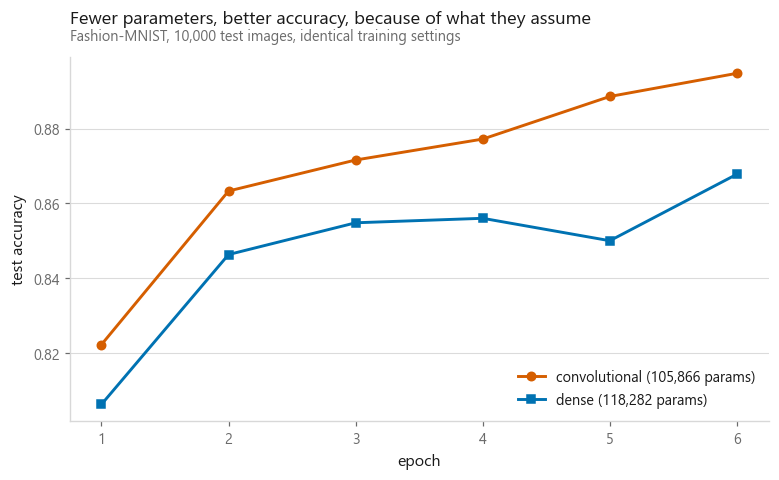

In [6]:
fig, ax = plt.subplots(figsize=(8.2, 4.3))
epochs = range(1, len(cnn_history["val_acc"]) + 1)
ax.plot(epochs, cnn_history["val_acc"], marker=style.MARKERS[0], color=style.HIGHLIGHT,
        label=f"convolutional ({count(SmallCNN()):,} params)")
ax.plot(epochs, dense_history["val_acc"], marker=style.MARKERS[1], color=style.PALETTE[0],
        label=f"dense ({count(DenseNet()):,} params)")
ax.set_xlabel("epoch")
ax.set_ylabel("test accuracy")
ax.legend(loc="lower right")
style.title(ax, "Fewer parameters, better accuracy, because of what they assume",
            "Fashion-MNIST, 10,000 test images, identical training settings")
style.save(fig, FIG / "fig-03-cnn-vs-dense.png")

The convolutional network wins **with fewer parameters**, which is the point.
This is not extra capacity; it is better assumptions. The convolution knows the
input is a grid and that patterns repeat across it. The dense layer has to
discover both facts from data, and it never fully does.

## 5. What the filters learned

Nobody specified edge detectors. They appeared because they were useful.


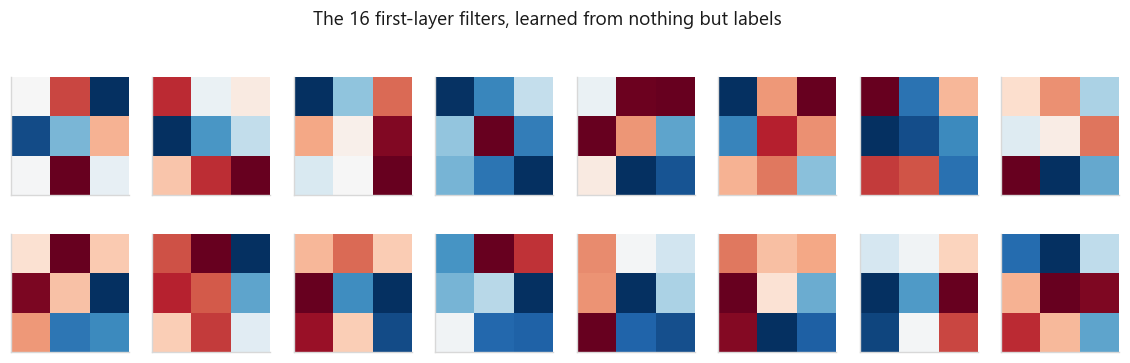

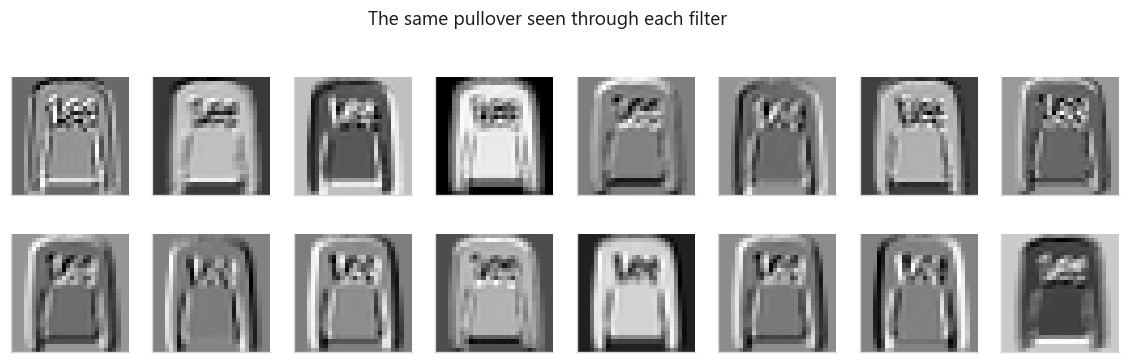

In [7]:
weights = cnn.features[0].weight.detach().cpu()

fig, axes = plt.subplots(2, 8, figsize=(13.0, 3.4))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(weights[i, 0], cmap="RdBu_r")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("The 16 first-layer filters, learned from nothing but labels",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-learned-filters.png")

sample = test_set[1][0].unsqueeze(0).to(device)
with torch.no_grad():
    activations = cnn.features[0](sample).cpu().squeeze()

fig, axes = plt.subplots(2, 8, figsize=(13.0, 3.4))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(activations[i], cmap="gray_r")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle(f"The same {CLASSES[test_set[1][1]]} seen through each filter",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-activations.png")

print("Nobody specified edge detectors. They appeared because they were useful.")

Compare these to the hand-designed Sobel filters at the top of the notebook.
Several of the learned ones have the same structure: positive on one side,
negative on the other, which is an edge detector. **Nobody asked for that.** It
emerged because detecting edges is useful for telling a sandal from a boot.

### Where the mistakes are

recall by class, worst first:
shirt       0.784
coat        0.790
T-shirt     0.792
pullover    0.797
dress       0.946
sneaker     0.950
bag         0.966
boot        0.970
sandal      0.972
trouser     0.981


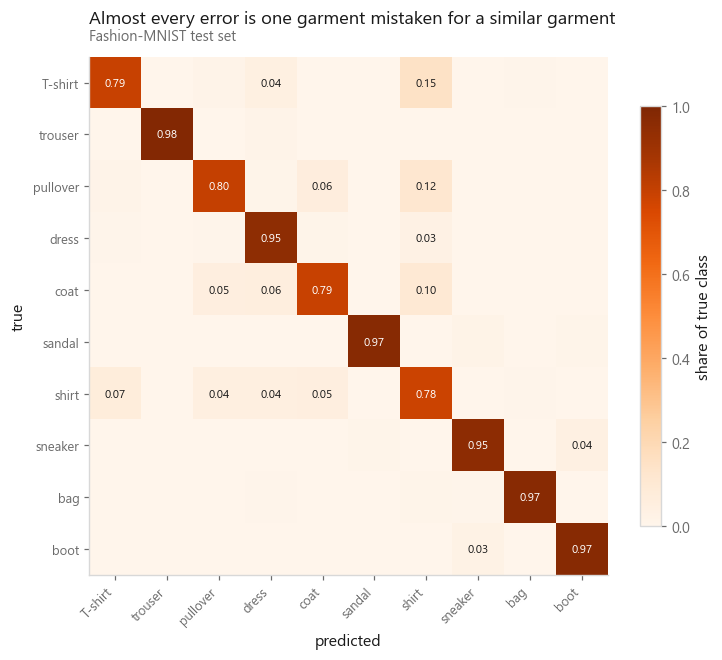

In [8]:
from sklearn.metrics import confusion_matrix

cnn.eval()
predictions, truths = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        predictions.append(cnn(xb.to(device)).argmax(1).cpu())
        truths.append(yb)
predictions, truths = torch.cat(predictions).numpy(), torch.cat(truths).numpy()

matrix = confusion_matrix(truths, predictions, normalize="true")

fig, ax = plt.subplots(figsize=(7.6, 6.2))
image = ax.imshow(matrix, cmap="Oranges", vmin=0, vmax=1)
for i in range(10):
    for j in range(10):
        if matrix[i, j] >= 0.02:
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if matrix[i, j] > 0.55 else style.INK)
ax.set_xticks(range(10), CLASSES, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(10), CLASSES, fontsize=8.5)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="share of true class")
style.title(ax, "Almost every error is one garment mistaken for a similar garment",
            "Fashion-MNIST test set")
style.save(fig, FIG / "fig-06-confusion.png")

recall = pd.Series(matrix.diagonal(), index=CLASSES).sort_values()
print("recall by class, worst first:")
print(recall.round(3).to_string())

The errors are not random. Shirts, pullovers, coats and T-shirts trade with each
other, because at 28×28 in greyscale they genuinely do look alike, sleeves and
a torso-shaped blob. Trousers, bags and boots are almost never confused with
anything, because their silhouettes are distinctive.

A model whose mistakes are the ones a human would also make is a model that has
learned something real. Errors scattered evenly across the matrix would suggest
it had not.

## Cheat sheet

| | |
|---|---|
| **Use it when** | The input is a grid where position matters and patterns repeat: images, spectrograms, some time series |
| **Avoid it when** | Features have no spatial relationship. On tabular data a convolution is meaningless |
| **The trick** | Weight sharing. One filter, reused everywhere, so parameters do not scale with input size |
| **Standard block** | `Conv → ReLU → Pool`, repeated, with channels doubling as resolution halves |
| **Padding** | `padding=1` with a 3×3 kernel preserves size. Without it every layer shrinks the image |
| **Watch out** | The flatten into the first dense layer usually holds most of the parameters. That is where overfitting starts |

## What to remember

1. A convolution slides one small filter over the whole input, reusing its weights.
2. That gives far fewer parameters and detection that works anywhere in the image.
3. Pooling shrinks the map and adds tolerance to small shifts.
4. The CNN beat the dense net **with fewer parameters**, better assumptions, not
   more capacity.
5. First-layer filters learn edge detectors on their own, resembling the Sobel
   kernels nobody told them about.
6. Read the confusion matrix. Sensible mistakes mean real learning.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [08-04 Data augmentation](../04-data-augmentation/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#CNN` `#ConvolutionalNeuralNetwork` `#ComputerVision` `#PyTorch`
`#FashionMNIST` `#MachineLearning` `#Python` `#MLTutorial` `#AI`